# Certifiable Rotation Averaging on $SO(3)$

This notebook solves a small graph of noncommuting three-dimensional rotations with GTSAM's Burer–Monteiro Riemannian Staircase. It illustrates the same certifiable pipeline as the planar example while starting at rank three and rounding $3\times3$ matrix variables.

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation, Atlanta, Georgia 30332-0415  
All Rights Reserved  
Authors: Frank Dellaert, et al. (see THANKS for the full author list)  
See LICENSE for the license information

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/CertifiableRotationAveragingRot3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the current GTSAM development package when running in Colab.
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np

import gtsam
from gtsam.symbol_shorthand import X

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7)

## Noncommuting rotations with loop closures

The ground-truth orientations combine roll, pitch, and yaw, so they do not stay inside a common one-dimensional subgroup. Consecutive edges form a cycle and three additional loop closures constrain the graph. For every edge, the exact relative measurement is $R_{ij}=R_i^\top R_j$.

In [3]:
num_rotations = 5
ground_truth = [
    gtsam.Rot3.RzRyRx(0.16 * index, -0.10 * index, 0.13 * index)
    for index in range(num_rotations)
]
edges = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 0),
    (0, 2), (1, 3), (2, 4),
]

graph = gtsam.NonlinearFactorGraph()
for source, target in edges:
    graph.add(
        gtsam.FrobeniusBetweenFactorRot3(
            X(source),
            X(target),
            ground_truth[source].between(ground_truth[target]),
        )
    )

initial = gtsam.Values()
initial_matrices = []
for index, rotation in enumerate(ground_truth):
    tangent_perturbation = rng.normal(scale=0.10, size=3)
    perturbed = rotation.compose(gtsam.Rot3.Expmap(tangent_perturbation))
    initial_matrices.append(perturbed.matrix())
    initial.insert(X(index), perturbed.matrix().T)

print(f"{graph.size()} relative-rotation factors, {initial.size()} variables")

8 relative-rotation factors, 5 variables


## Run and certify the rank-three relaxation

The local augmented-Lagrangian solver enforces the quadratic orthogonality constraints. The outer staircase verifies the SDP certificate and lifts the factorization rank only when necessary.

In [4]:
alm_params = gtsam.AugmentedLagrangianParams()
alm_params.maxIterations = 100
alm_params.absoluteViolationTolerance = 1e-8

params = gtsam.RiemannianStaircaseParams()
params.pMin = 3
params.pMax = 5
params.eta = 1e-3
params.setAlmParams(alm_params)

start = time.perf_counter()
result = gtsam.RiemannianStaircaseOptimizer(graph, initial, params).optimize()
wall_time = time.perf_counter() - start

print(f"Certified: {result.certified}")
print(f"Final rank: {result.finalRank}")
print(f"Certificate lower bound / minimum eigenvalue: {result.minEigenvalue:.3e}")
print(f"Solver time: {result.totalTime:.3f} s; notebook wall time: {wall_time:.3f} s")

Certified: True
Final rank: 3
Certificate lower bound / minimum eigenvalue: -1.000e-03
Solver time: 0.001 s; notebook wall time: 0.001 s


## Round, project, and fix the global gauge

The rank-three QCQP blocks store $X_i=R_i^\top$ and share an $O(3)$ gauge. We first choose a consistent determinant sign, transpose and project every block to the closest proper rotation with SVD, and then apply one common left rotation so the first estimate matches the first ground-truth orientation.

In [5]:
if not result.hasRoundedSolution():
    raise RuntimeError("The staircase did not return a rounded solution.")

def project_to_so(matrix):
    """Return the closest proper rotation to a square matrix."""
    left, _, right_transpose = np.linalg.svd(matrix)
    correction = np.eye(matrix.shape[0])
    correction[-1, -1] = np.linalg.det(left @ right_transpose)
    return left @ correction @ right_transpose

rounded_values = result.roundedValues()
rounded_blocks = [rounded_values.atMatrix(X(i)).copy() for i in range(num_rotations)]
if sum(np.linalg.det(block) < 0.0 for block in rounded_blocks) > num_rotations // 2:
    for block in rounded_blocks:
        block[:, -1] *= -1.0

rounded_rotations = [project_to_so(block.T) for block in rounded_blocks]
truth_matrices = [rotation.matrix() for rotation in ground_truth]

def gauge_align(rotations, reference):
    gauge = reference[0] @ rotations[0].T
    return [gauge @ rotation for rotation in rotations]

initial_aligned = gauge_align(initial_matrices, truth_matrices)
rounded_aligned = gauge_align(rounded_rotations, truth_matrices)

def rotation_error_degrees(estimate, truth):
    relative = truth.T @ estimate
    cosine = np.clip((np.trace(relative) - 1.0) / 2.0, -1.0, 1.0)
    return np.rad2deg(np.arccos(cosine))

initial_error = np.array([
    rotation_error_degrees(estimate, truth)
    for estimate, truth in zip(initial_aligned, truth_matrices)
])
rounded_error = np.array([
    rotation_error_degrees(estimate, truth)
    for estimate, truth in zip(rounded_aligned, truth_matrices)
])

print(f"Maximum initial orientation error: {initial_error.max():.3f} deg")
print(f"Maximum rounded orientation error: {rounded_error.max():.3e} deg")

Maximum initial orientation error: 7.601 deg
Maximum rounded orientation error: 0.000e+00 deg


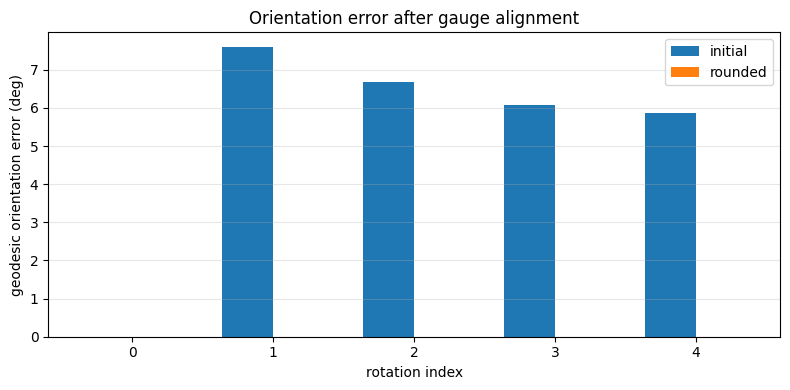

In [6]:
indices = np.arange(num_rotations)
width = 0.36
fig, axis = plt.subplots(figsize=(8, 4))
axis.bar(indices - width / 2, initial_error, width, label="initial")
axis.bar(indices + width / 2, rounded_error, width, label="rounded")
axis.set(
    xlabel="rotation index",
    ylabel="geodesic orientation error (deg)",
    title="Orientation error after gauge alignment",
    xticks=indices,
)
axis.grid(axis="y", alpha=0.3)
axis.legend()
plt.tight_layout()

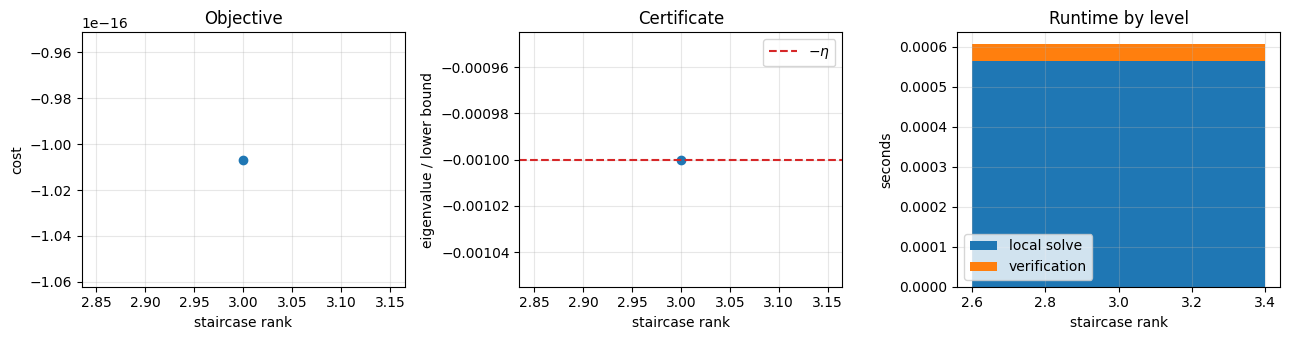

In [7]:
ranks = np.asarray(result.getRanksVisited())
costs = np.asarray(result.getCostPerLevel())
eigenvalues = np.asarray(result.getMinEigenvaluePerLevel())
build_times = np.asarray(result.getQcqpBuildTimePerLevel())
nlp_times = np.asarray(result.getNlpTimePerLevel())
verify_times = np.asarray(result.getVerifyTimePerLevel())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(ranks, costs, "o-")
axes[0].set(xlabel="staircase rank", ylabel="cost", title="Objective")
axes[1].plot(ranks, eigenvalues, "o-")
axes[1].axhline(-params.eta, color="tab:red", linestyle="--", label="$-\\eta$")
axes[1].set(xlabel="staircase rank", ylabel="eigenvalue / lower bound", title="Certificate")
axes[1].legend()
axes[2].bar(ranks, build_times, label="QCQP build")
axes[2].bar(ranks, nlp_times, bottom=build_times, label="local solve")
axes[2].bar(ranks, verify_times, bottom=build_times + nlp_times, label="verification")
axes[2].set(xlabel="staircase rank", ylabel="seconds", title="Runtime by level")
axes[2].legend()
for axis in axes:
    axis.grid(alpha=0.3)
plt.tight_layout()

The rank-three factorization is sufficient for this graph, and the certificate verifies the SDP relaxation at that level. Projection and gauge alignment convert the generic matrix-valued result into directly interpretable $SO(3)$ orientations.